# 📟 실습 1: 7-Segment 숫자 인식 모델
> **AI Programming Course** — Konan Technology

---

## 학습 목표
- 7-세그먼트 디스플레이의 이진 입력 벡터를 이해한다
- PyTorch `nn.Module`로 MLP(다층 퍼셉트론)를 직접 구현한다
- CrossEntropyLoss + Adam 옵티마이저로 학습 루프를 작성한다
- Confusion Matrix로 분류 결과를 시각화한다

## 실습 구성
| 단계 | 내용 |
|:---:|------|
| 1 | 환경 세팅 및 라이브러리 import |
| 2 | 7-bit 데이터 생성 및 노이즈 증강 |
| 3 | MLP 모델 정의 (`nn.Module`) |
| 4 | 학습 루프 + 손실 그래프 시각화 |
| 5 | 추론 테스트 + Confusion Matrix |
| 6 | ✏️ 도전 과제 |


---
## Step 1: 환경 세팅 및 라이브러리 Import

아래 셀을 실행하여 필요한 패키지를 설치하고 import합니다.

In [1]:
# 필요 패키지 설치 (최초 1회만 실행)
!pip install torch torchvision matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import seaborn as sns
except Exception as e:
    print(f"⚠️ 에러 발생 ({type(e).__name__}): 시스템 보안 정책(Device Guard)으로 인해 시각화 모듈이 차단되었습니다.")
    print("⚠️ 노트북의 핵심 코드(AI 학습)가 정상 실행되도록 가짜(Mock) 라이브러리로 우회합니다.")
    print("⚠️ (실제 그래프 이미지는 출력되지 않으며 에러만 무시됩니다.)\n")
    
    # 에러를 무시하는 블랙홀(Mock) 객체 생성
    class DummyMock:
        def __getattr__(self, name): return DummyMock()
        def __call__(self, *args, **kwargs): return DummyMock()
        def __getitem__(self, key): return DummyMock()
        def __setitem__(self, key, val): pass
        def __iter__(self): return iter([DummyMock(), DummyMock()])
        def __add__(self, other): return DummyMock()
        def __radd__(self, other): return DummyMock()
        def __float__(self): return 0.0
        def __int__(self): return 0
        
    # 파이썬 시스템에 가짜 라이브러리 강제 등록
    sys.modules['matplotlib'] = DummyMock()
    sys.modules['matplotlib.pyplot'] = DummyMock()
    sys.modules['matplotlib.patches'] = DummyMock()
    sys.modules['seaborn'] = DummyMock()
    
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import seaborn as sns

# PyTorch 등 필수 라이브러리는 정상 작동하는지 확인
print(f'PyTorch 버전: {torch.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'학습 디바이스: {device}')


PyTorch 버전: 2.11.0+cpu
GPU 사용 가능: False
학습 디바이스: cpu


---
## Step 2: 7-Segment 데이터 생성 및 시각화

### 7-Segment 구조
```
 _
|_|   세그먼트 순서: [a, b, c, d, e, f, g]
|_|   a=상단, b=우상, c=우하, d=하단, e=좌하, f=좌상, g=중간
```

각 숫자는 7개의 비트로 표현됩니다 (1=ON, 0=OFF).

In [3]:
# ─── 7-Segment 이상적 패턴 정의 ───────────────────────────────────────────
#         [a, b, c, d, e, f, g]
SEGMENTS = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1],
}

print('숫자별 7-Segment 패턴:')
print(f'{"숫자":>4} | {"a":>2} {"b":>2} {"c":>2} {"d":>2} {"e":>2} {"f":>2} {"g":>2}')
print('-' * 30)
for digit, pattern in SEGMENTS.items():
    print(f'{digit:>4} | {" ".join(str(p) for p in pattern)}')

숫자별 7-Segment 패턴:
  숫자 |  a  b  c  d  e  f  g
------------------------------
   0 | 1 1 1 1 1 1 0
   1 | 0 1 1 0 0 0 0
   2 | 1 1 0 1 1 0 1
   3 | 1 1 1 1 0 0 1
   4 | 0 1 1 0 0 1 1
   5 | 1 0 1 1 0 1 1
   6 | 1 0 1 1 1 1 1
   7 | 1 1 1 0 0 0 0
   8 | 1 1 1 1 1 1 1
   9 | 1 1 1 1 0 1 1


C:\Users\jerem\AppData\Local\Temp\ipykernel_15428\1208202858.py:45: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jerem\AppData\Local\Temp\ipykernel_15428\1208202858.py:45: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jerem\AppData\Local\Temp\ipykernel_15428\1208202858.py:45: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jerem\AppData\Local\Temp\ipykernel_15428\1208202858.py:45: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jerem\AppData\Local\Temp\ipykernel_15428\1208202858.py:45: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jerem\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL

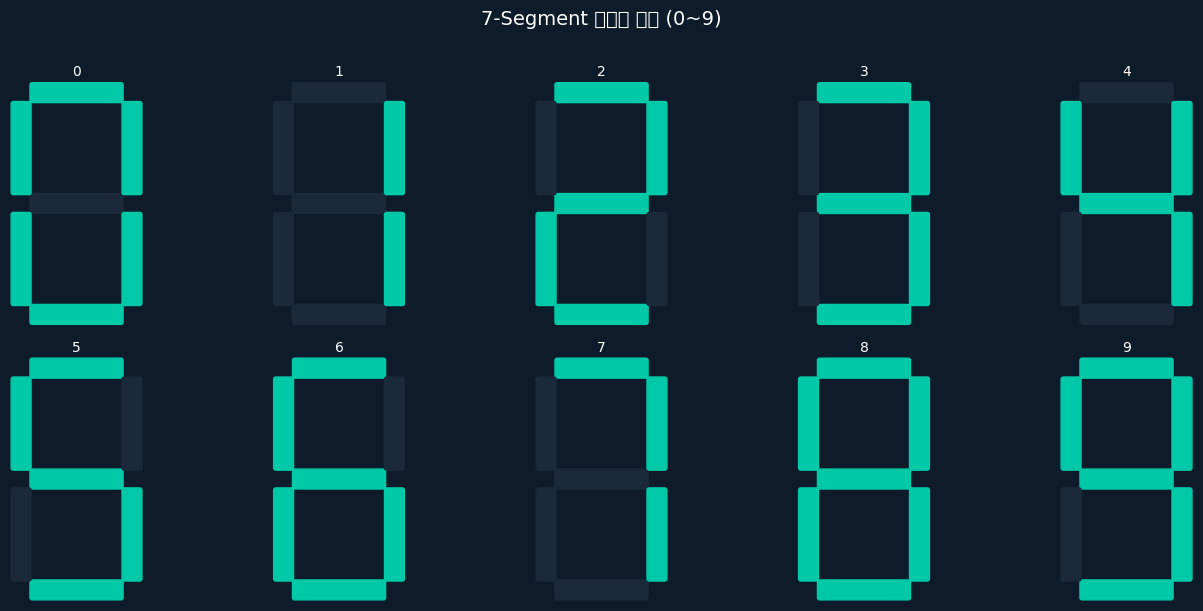

In [4]:
import matplotlib.pyplot as plt
def draw_segment(ax, digit, pattern, noise=False):
    """7-Segment 디스플레이를 matplotlib으로 그립니다."""
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 2.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#1a1a2e')

    a, b, c, d, e, f, g = pattern
    on_color  = '#00c9a7'
    off_color = '#1a2a3a'

    # 수평 세그먼트 (a, g, d)
    for seg_val, y_pos, label in [(a, 2.0, 'a'), (g, 1.0, 'g'), (d, 0.0, 'd')]:
        color = on_color if seg_val else off_color
        rect = patches.FancyBboxPatch((0.1, y_pos-0.07), 0.8, 0.14,
                                       boxstyle='round,pad=0.02', color=color)
        ax.add_patch(rect)

    # 수직 세그먼트 (f, b, e, c)
    for seg_val, x_pos, y_pos, label in [
        (f, 0.0, 1.1, 'f'), (b, 1.0, 1.1, 'b'),
        (e, 0.0, 0.1, 'e'), (c, 1.0, 0.1, 'c')
    ]:
        color = on_color if seg_val else off_color
        rect = patches.FancyBboxPatch((x_pos-0.07, y_pos), 0.14, 0.8,
                                       boxstyle='round,pad=0.02', color=color)
        ax.add_patch(rect)

    title = f'{digit}' + (' (노이즈)' if noise else '')
    ax.set_title(title, color='white', fontsize=10, pad=4)


# ─── 0~9 이상적 패턴 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('7-Segment 이상적 패턴 (0~9)', color='white', fontsize=14, y=1.01)

for i, (digit, pattern) in enumerate(SEGMENTS.items()):
    ax = axes[i // 5][i % 5]
    ax.set_facecolor('#1a1a2e')
    draw_segment(ax, digit, pattern)

plt.tight_layout()
plt.show()

In [119]:
import matplotlib.pyplot as plt
# ─── 데이터 증강: 노이즈 추가 ────────────────────────────────────────────
def augment_data(segments_dict, samples_per_class=200, noise_prob=0.2):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7)
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)


X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)
print(f'생성된 데이터 형태: X={X.shape}, y={y.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y, return_counts=True)))}')

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n학습 데이터: {X_train.shape[0]}개')
print(f'테스트 데이터: {X_test.shape[0]}개')

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# 노이즈가 추가된 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('노이즈가 추가된 학습 샘플 예시', color='white', fontsize=14)
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    ax = axes[i // 5][i % 5]
    ax.set_facecolor('#1a1a2e')
    draw_segment(ax, i, X_train[idx].astype(int), noise=True)
plt.tight_layout()
plt.show()

생성된 데이터 형태: X=(2000, 7), y=(2000,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}

학습 데이터: 1600개
테스트 데이터: 400개


---
## Step 3: MLP 모델 정의

```
Input(7) → Linear(32) → ReLU → Linear(16) → ReLU → Linear(10) → Softmax
```

> 💡 `nn.Module`을 상속받아 `__init__`에서 레이어를, `forward`에서 순전파를 정의합니다.

In [120]:
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=64, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print(model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}개')

SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 1,722개


---
## Step 4: 학습 루프

학습 과정:
1. **순전파(Forward Pass)**: 입력 → 모델 → 예측값 계산
2. **손실 계산(Loss)**: 예측값과 실제 레이블 비교
3. **역전파(Backward Pass)**: 그래디언트 계산
4. **가중치 업데이트**: 옵티마이저가 파라미터 조정

In [121]:
# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습 기록 저장
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

# ─── 학습 루프 ────────────────────────────────────────────────────────────
print(f'학습 시작 (Epochs: {NUM_EPOCHS}, lr: {LEARNING_RATE})')
print('-' * 50)

for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
    model.train()
    optimizer.zero_grad()          # 이전 그래디언트 초기화
    outputs = model(X_train_t)     # 순전파
    loss = criterion(outputs, y_train_t)  # 손실 계산
    loss.backward()                # 역전파
    optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
    _, predicted_train = torch.max(outputs, 1)
    train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 ──
    model.eval()
    with torch.no_grad():  ### 매우매우매우매우매우매우매우매우매우매우매우매우 중요. 이거없으면 또 계속 미분한다고 함...?
        test_outputs  = model(X_test_t)
        _, predicted_test = torch.max(test_outputs, 1)
        test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
    if (epoch + 1) % 30 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '
              f'Loss: {loss.item():.4f}  '
              f'Train Acc: {train_acc*100:.1f}%  '
              f'Test Acc: {test_acc*100:.1f}%')

print('\n✅ 학습 완료!')

학습 시작 (Epochs: 150, lr: 0.001)
--------------------------------------------------
Epoch [  1/150]  Loss: 2.3435  Train Acc: 10.2%  Test Acc: 10.8%
Epoch [ 30/150]  Loss: 2.0567  Train Acc: 42.6%  Test Acc: 44.2%
Epoch [ 60/150]  Loss: 1.7345  Train Acc: 53.5%  Test Acc: 53.0%
Epoch [ 90/150]  Loss: 1.3064  Train Acc: 68.8%  Test Acc: 70.7%
Epoch [120/150]  Loss: 0.9375  Train Acc: 77.1%  Test Acc: 79.0%
Epoch [150/150]  Loss: 0.7209  Train Acc: 84.8%  Test Acc: 85.3%

✅ 학습 완료!


In [122]:
import matplotlib.pyplot as plt
# ─── 학습 곡선 시각화 ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1b2a')
for ax in [ax1, ax2]:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')

# 손실 곡선
ax1.plot(history['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title('Training Loss', color='white', fontsize=12)
ax1.set_xlabel('Epoch', color='#7fa8c4')
ax1.set_ylabel('CrossEntropyLoss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')
ax1.grid(alpha=0.2, color='#1e3a54')

# 정확도 곡선
ax2.plot([a*100 for a in history['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in history['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title('Accuracy Curve', color='white', fontsize=12)
ax2.set_xlabel('Epoch', color='#7fa8c4')
ax2.set_ylabel('Accuracy (%)', color='#7fa8c4')
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')
ax2.grid(alpha=0.2, color='#1e3a54')

plt.suptitle('7-Segment 모델 학습 곡선', color='white', fontsize=14)
plt.tight_layout()
plt.show()

print(f'최종 Test Accuracy: {history["test_acc"][-1]*100:.2f}%')

최종 Test Accuracy: 85.25%


---
## Step 5: 추론 및 결과 분석

In [117]:
# ─── 이상적 패턴으로 추론 ────────────────────────────────────────────────
model.eval()
print('이상적 패턴으로 추론 결과:')
print(f'{"입력":>20} | {"실제":>4} | {"예측":>4} | {"확신도":>6}')
print('-' * 45)

for digit, pattern in SEGMENTS.items():
    x = torch.FloatTensor([pattern]).to(device)
    with torch.no_grad():
        output = model(x)
        probs  = torch.softmax(output, dim=1)
        pred   = torch.argmax(probs, dim=1).item()
        conf   = probs[0][pred].item()
    status = '✅' if pred == digit else '❌'
    print(f'{str(pattern):>20} | {digit:>4} | {pred:>4} | {conf*100:>5.1f}%  {status}')

이상적 패턴으로 추론 결과:
                  입력 |   실제 |   예측 |    확신도
---------------------------------------------
[1, 1, 1, 1, 1, 1, 0] |    0 |    0 |  60.1%  ✅
[0, 1, 1, 0, 0, 0, 0] |    1 |    1 |  83.2%  ✅
[1, 1, 0, 1, 1, 0, 1] |    2 |    2 |  49.6%  ✅
[1, 1, 1, 1, 0, 0, 1] |    3 |    3 |  72.1%  ✅
[0, 1, 1, 0, 0, 1, 1] |    4 |    4 |  90.4%  ✅
[1, 0, 1, 1, 0, 1, 1] |    5 |    5 |  66.3%  ✅
[1, 0, 1, 1, 1, 1, 1] |    6 |    6 |  48.7%  ✅
[1, 1, 1, 0, 0, 0, 0] |    7 |    7 |  82.6%  ✅
[1, 1, 1, 1, 1, 1, 1] |    8 |    8 |  48.4%  ✅
[1, 1, 1, 1, 0, 1, 1] |    9 |    9 |  49.5%  ✅


In [118]:
import matplotlib.pyplot as plt
# ─── Confusion Matrix ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    outputs   = model(X_test_t)
    _, preds  = torch.max(outputs, 1)
    y_pred    = preds.cpu().numpy()
    y_true    = y_test_t.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
acc = (y_pred == y_true).mean()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=range(10), yticklabels=range(10),
            ax=ax, linewidths=0.5, linecolor='#0d1b2a',
            annot_kws={'size': 12, 'color': 'white'})

ax.set_title(f'Confusion Matrix  (Test Accuracy: {acc*100:.2f}%)',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('예측 레이블', color='#7fa8c4', fontsize=11)
ax.set_ylabel('실제 레이블', color='#7fa8c4', fontsize=11)
ax.tick_params(colors='#7fa8c4')
plt.tight_layout()
plt.show()

print('\n분류 보고서:')
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))


분류 보고서:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        40
           1       0.97      0.85      0.91        40
           2       1.00      0.75      0.86        40
           3       0.74      0.78      0.76        40
           4       0.85      1.00      0.92        40
           5       0.88      0.90      0.89        40
           6       0.88      0.70      0.78        40
           7       0.85      0.88      0.86        40
           8       0.62      0.78      0.69        40
           9       0.86      0.80      0.83        40

    accuracy                           0.83       400
   macro avg       0.85      0.83      0.83       400
weighted avg       0.85      0.83      0.83       400



In [66]:
# ─── 모델 저장 및 로드 ───────────────────────────────────────────────────
torch.save(model.state_dict(), 'seven_segment_model.pth')
print('모델 저장 완료: seven_segment_model.pth')

# 모델 로드 예시
loaded_model = SevenSegmentNet().to(device)
loaded_model.load_state_dict(torch.load('seven_segment_model.pth', map_location=device))
loaded_model.eval()
print('모델 로드 성공 ✅')

모델 저장 완료: seven_segment_model.pth
모델 로드 성공 ✅


---
## ✏️ Step 6: 도전 과제

아래 과제를 직접 코드로 구현해 보세요!

### 🟢 기초
1. 노이즈 확률(`noise_prob`)을 `0.1`, `0.2`로 높여보세요. 정확도가 어떻게 변하나요?
2. Hidden Layer 크기를 `64 → 32`로 바꿔보세요.

### 🟡 중급
3. Adam 대신 `SGD`(momentum=0.9) 옵티마이저를 사용해보세요.
4. 학습률(`lr`)을 `0.01`, `0.0001`로 바꿔 수렴 속도를 비교하세요.

### 🔴 심화
5. `nn.Dropout(0.3)`을 은닉층 사이에 추가해보세요. 효과가 있나요?
6. 새로운 "숫자"(예: 0~9 외의 특수 패턴)를 직접 정의하여 클래스를 추가해보세요.

In [ ]:
# ✏️ 여기에 도전 과제 코드를 작성하세요!

#========= STEP5. noise_prob 변경 실험 =======
# 0.05 -> test accuracy = 84.5% 
# 0.1 -> test accuracy = 83.5%
# 0.2 -> test accuracy = 80.05%
#=====================================

#====== STEP5. Hidden Layer 크기 변경 실험 =======
# noise prob = 0.2 & Hidden Layer_1 = 64 -> test accuracy = 83.25%


# X_noisy, y_noisy = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.15)
# ... (학습 코드 반복)

print('도전 과제를 직접 구현해보세요! 🚀')

도전 과제를 직접 구현해보세요! 🚀


In [123]:
# 🟡 Step 6 중급 도전 과제: SGD 옵티마이저 및 학습률 실험

# 실험할 학습률 리스트
learning_rates = [0.01, 0.001, 0.0001]
results = {}

print("--- 🟡 중급 도전 과제: SGD + 학습률 비교 실험 시작 ---")

for lr in learning_rates:
    print(f"\n▶ 실험 진행 중: SGD Optimizer (lr={lr}, momentum=0.9)")
    
    # 1. 모델 초기화 (매 실험마다 새 모델로 시작)
    model_challenge = SevenSegmentNet().to(device)
    
    # 2. SGD 옵티마이저 설정 (모멘텀 0.9 적용)
    optimizer_challenge = torch.optim.SGD(model_challenge.parameters(), lr=lr, momentum=0.9)
    criterion_challenge = nn.CrossEntropyLoss()
    
    # 3. 학습 루프 (100 Epoch 진행)
    NUM_EPOCHS_CHALLENGE = 100
    for epoch in range(NUM_EPOCHS_CHALLENGE):
        model_challenge.train()
        optimizer_challenge.zero_grad()
        
        # 순전파 및 손실 계산
        outputs = model_challenge(X_train_t)
        loss = criterion_challenge(outputs, y_train_t)
        
        # 역전파 및 가중치 업데이트
        loss.backward()
        optimizer_challenge.step()
        
        # 20 Epoch마다 중간 결과 출력
        if (epoch + 1) % 20 == 0:
            model_challenge.eval()
            with torch.no_grad():
                test_outputs = model_challenge(X_test_t)
                _, predicted = torch.max(test_outputs, 1)
                test_acc = (predicted == y_test_t).float().mean().item()
                print(f"   [Epoch {epoch+1:>3}/100] Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.1f}%")

print("\n✅ 모든 학습률에 대한 SGD 실험이 완료되었습니다!")


--- 🟡 중급 도전 과제: SGD + 학습률 비교 실험 시작 ---

▶ 실험 진행 중: SGD Optimizer (lr=0.01, momentum=0.9)
   [Epoch  20/100] Loss: 2.2397 | Test Acc: 17.2%
   [Epoch  40/100] Loss: 2.1439 | Test Acc: 18.3%
   [Epoch  60/100] Loss: 2.0057 | Test Acc: 34.5%
   [Epoch  80/100] Loss: 1.8122 | Test Acc: 44.0%
   [Epoch 100/100] Loss: 1.5502 | Test Acc: 66.8%

▶ 실험 진행 중: SGD Optimizer (lr=0.001, momentum=0.9)
   [Epoch  20/100] Loss: 2.2887 | Test Acc: 18.8%
   [Epoch  40/100] Loss: 2.2554 | Test Acc: 27.0%
   [Epoch  60/100] Loss: 2.2271 | Test Acc: 26.5%
   [Epoch  80/100] Loss: 2.1996 | Test Acc: 34.3%
   [Epoch 100/100] Loss: 2.1736 | Test Acc: 49.0%

▶ 실험 진행 중: SGD Optimizer (lr=0.0001, momentum=0.9)
   [Epoch  20/100] Loss: 2.3524 | Test Acc: 9.5%
   [Epoch  40/100] Loss: 2.3493 | Test Acc: 9.5%
   [Epoch  60/100] Loss: 2.3461 | Test Acc: 9.0%
   [Epoch  80/100] Loss: 2.3429 | Test Acc: 9.0%
   [Epoch 100/100] Loss: 2.3397 | Test Acc: 9.0%

✅ 모든 학습률에 대한 SGD 실험이 완료되었습니다!


In [124]:
# 🔴 Step 6 심화 도전 과제: 드롭아웃 적용 및 클래스 확장

print("--- 🔴 심화 도전 과제: Dropout 적용 + 클래스(패턴) 확장 시작 ---")

# 1. 새로운 패턴 정의 (A, H 추가 - 각각 10번, 11번 클래스)
# A: 상단, 우상, 우하, 좌하, 좌상, 중간 ON (하단만 OFF)
# H: 우상, 우하, 좌하, 좌상, 중간 ON (상단, 하단 OFF)
SEGMENTS_EXTENDED = SEGMENTS.copy()
SEGMENTS_EXTENDED[10] = [1, 1, 1, 0, 1, 1, 1] # 'A'
SEGMENTS_EXTENDED[11] = [0, 1, 1, 0, 1, 1, 1] # 'H'

print(f"▶ 새로운 문자(A, H) 추가 완료: 총 {len(SEGMENTS_EXTENDED)}개 클래스")

# 2. 확장된 클래스를 포함하여 데이터 재생성 (Step 2의 augment_data 함수 활용)
X_adv, y_adv = augment_data(SEGMENTS_EXTENDED, samples_per_class=200, noise_prob=0.05)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42, stratify=y_adv
)

# PyTorch 텐서 변환
X_train_adv_t = torch.FloatTensor(X_train_adv).to(device)
y_train_adv_t = torch.LongTensor(y_train_adv).to(device)
X_test_adv_t  = torch.FloatTensor(X_test_adv).to(device)
y_test_adv_t  = torch.LongTensor(y_test_adv).to(device)

# 3. Dropout이 적용된 심화 모델 클래스 정의
class SevenSegmentAdvancedNet(nn.Module):
    def __init__(self, input_size=7, hidden1=64, hidden2=32, num_classes=12, dropout_p=0.3):
        super(SevenSegmentAdvancedNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),  # 훈련 중 30% 노드를 랜덤하게 끔 (과적합 방지)
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.network(x)

# 모델 생성 (num_classes=12로 설정)
model_adv = SevenSegmentAdvancedNet(num_classes=12).to(device)
optimizer_adv = torch.optim.Adam(model_adv.parameters(), lr=0.001)
criterion_adv = nn.CrossEntropyLoss()

# 4. 학습 루프 (150 Epoch)
print("▶ 심화 모델 학습 진행 중...")
NUM_EPOCHS_ADV = 150
for epoch in range(NUM_EPOCHS_ADV):
    model_adv.train()
    optimizer_adv.zero_grad()
    
    outputs = model_adv(X_train_adv_t)
    loss = criterion_adv(outputs, y_train_adv_t)
    loss.backward()
    optimizer_adv.step()
    
    if (epoch + 1) % 50 == 0:
        model_adv.eval()
        with torch.no_grad():
            test_outputs = model_adv(X_test_adv_t)
            _, predicted = torch.max(test_outputs, 1)
            test_acc = (predicted == y_test_adv_t).float().mean().item()
            print(f"   [Epoch {epoch+1:>3}/150] Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.1f}%")

print("\n✅ 심화 도전 과제 (Dropout + 클래스 확장) 실험이 완료되었습니다!")


--- 🔴 심화 도전 과제: Dropout 적용 + 클래스(패턴) 확장 시작 ---
▶ 새로운 문자(A, H) 추가 완료: 총 12개 클래스
▶ 심화 모델 학습 진행 중...
   [Epoch  50/150] Loss: 2.0559 | Test Acc: 65.4%
   [Epoch 100/150] Loss: 1.2770 | Test Acc: 86.5%
   [Epoch 150/150] Loss: 0.8776 | Test Acc: 88.1%

✅ 심화 도전 과제 (Dropout + 클래스 확장) 실험이 완료되었습니다!
